In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/WM-811K-project'

os.makedirs(f'{BASE}/data', exist_ok=True)
os.makedirs(f'{BASE}/outputs', exist_ok=True)

print("Folder ready:", BASE)

Mounted at /content/drive
Folder ready: /content/drive/MyDrive/WM-811K-project


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"jeniffar1","key":"88f1ef5747cd16c77fa0b6e90bb6f446"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Key installed")

Key installed


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d qingyi/wm811k-wafer-map -p /content
!unzip -q /content/wm811k-wafer-map.zip -d /content
!ls -lh /content/*.pkl

Dataset URL: https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map
License(s): CC0-1.0
100% 149M/149M [00:01<00:00, 86.6MB/s]

-rw-r--r-- 1 root root 2.0G Sep 27  2019 /content/LSWMD.pkl


In [ ]:
!cp /content/LSWMD.pkl "/content/drive/MyDrive/WM-811K-project/data/"
!ls -lh "/content/drive/MyDrive/WM-811K-project/data/"

cp: cannot stat '/content/LSWMD.pkl': No such file or directory
total 2.0G
-rw------- 1 root root 2.0G Sep 11 20:52 LSWMD.pkl


In [ ]:
import pandas as pd
import numpy as np

print("Loading... takes a few minutes.")
df = pd.read_pickle("/content/drive/MyDrive/WM-811K-project/data/LSWMD.pkl")
print("Done.")
print("Rows:", len(df))
print("Columns:", list(df.columns))

Loading... takes a few minutes.
Done.
Rows: 811457
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


In [ ]:
def flatten_label(v):
    if isinstance(v, (np.ndarray, list)):
        if len(v) == 0:
            return None
        v = v[0]
        if isinstance(v, (np.ndarray, list)):
            v = v[0] if len(v) else None
    if v is None:
        return None
    s = str(v).strip()
    return s if s else None

df['label'] = df.failureType.apply(flatten_label)
labeled = df[df.label.notna()]

print(f"Total wafers: {len(df):,}")
print(f"Labeled:      {len(labeled):,}  ({len(labeled)/len(df):.1%})")
print(f"Unlabeled:    {len(df)-len(labeled):,}")
print()
print(labeled.label.value_counts())

Total wafers: 811,457
Labeled:      172,950  (21.3%)
Unlabeled:    638,507

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [ ]:
defects = labeled[labeled.label != 'none'].copy()
print(f"Defect wafers: {len(defects):,}")
print(defects.label.value_counts())

Defect wafers: 25,519
label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


Shape: (45, 48)
Values present: [0 1 2]
Label: Loc


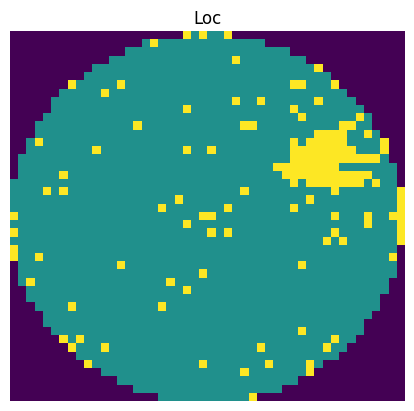

In [ ]:
import matplotlib.pyplot as plt

wafer = defects.iloc[0]['waferMap']
print("Shape:", wafer.shape)
print("Values present:", np.unique(wafer))
print("Label:", defects.iloc[0]['label'])

plt.imshow(wafer)
plt.title(defects.iloc[0]['label'])
plt.axis('off')
plt.show()

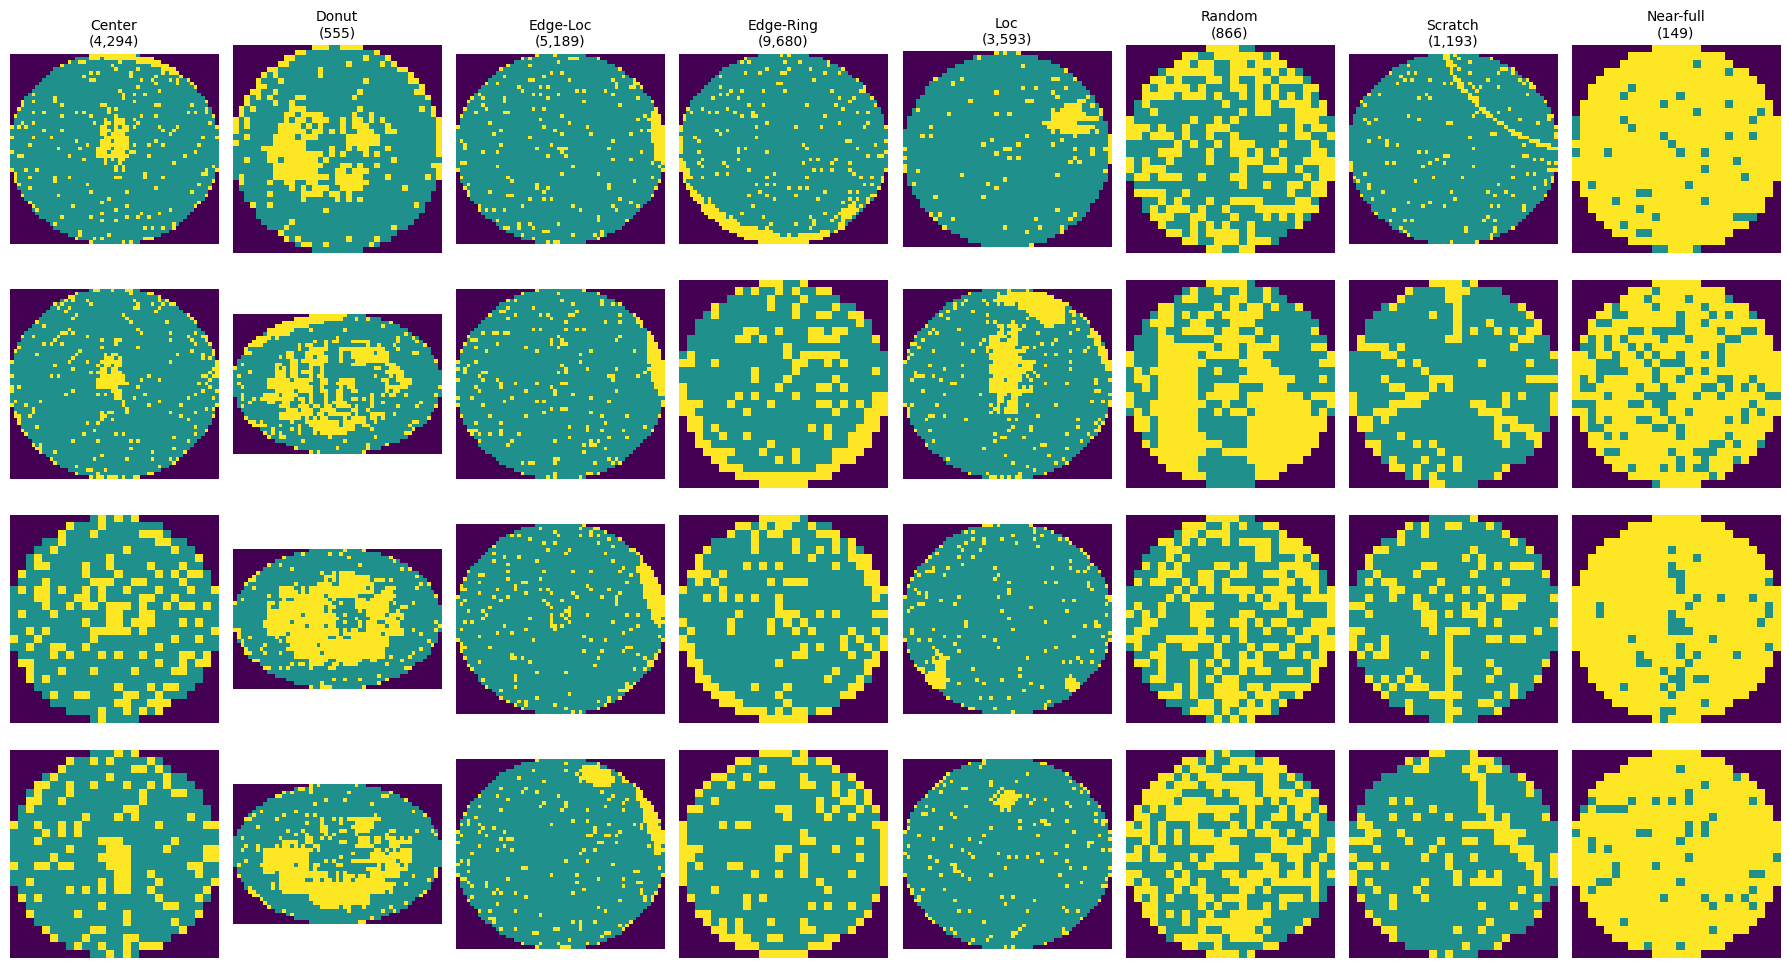

In [ ]:
classes = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']

fig, axes = plt.subplots(4, 8, figsize=(18, 10))

for col, cls in enumerate(classes):
    subset = defects[defects.label == cls]
    for row in range(4):
        ax = axes[row, col]
        ax.imshow(subset.iloc[row]['waferMap'])
        ax.axis('off')
        if row == 0:
            ax.set_title(f"{cls}\n({len(subset):,})", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
defects['shape'] = defects.waferMap.apply(lambda w: w.shape)
defects['height'] = defects.waferMap.apply(lambda w: w.shape[0])
defects['width']  = defects.waferMap.apply(lambda w: w.shape[1])

print("Number of different wafer sizes:", defects['shape'].nunique())
print()
print("10 most common sizes:")
print(defects['shape'].value_counts().head(10))
print()
print(f"Height range: {defects.height.min()} to {defects.height.max()}")
print(f"Width range:  {defects.width.min()} to {defects.width.max()}")

Number of different wafer sizes: 329

10 most common sizes:
shape
(25, 27)    2900
(38, 36)    2127
(53, 52)    1519
(63, 62)    1424
(39, 37)    1015
(26, 26)     877
(30, 34)     710
(35, 31)     648
(44, 41)     600
(29, 26)     555
Name: count, dtype: int64

Height range: 22 to 212
Width range:  18 to 204


In [ ]:
smallest = defects[defects.height < 20]
print(f"Wafers under 20 pixels tall: {len(smallest):,}")

tiny = defects[(defects.height < 15) | (defects.width < 15)]
print(f"Very small wafers (under 15 px): {len(tiny):,}")

print()
print("Size distribution:")
print(defects.height.describe())

Wafers under 20 pixels tall: 0
Very small wafers (under 15 px): 0

Size distribution:
count    25519.000000
mean        43.151534
std         18.278374
min         22.000000
25%         31.000000
50%         39.000000
75%         52.000000
max        212.000000
Name: height, dtype: float64


In [ ]:
def defect_density(wafer):
    valid = np.sum((wafer == 1) | (wafer == 2))   # all chips on the wafer
    failed = np.sum(wafer == 2)                    # the failed ones
    return 0 if valid == 0 else failed / valid

# test it on one wafer from each class
for cls in ['Center','Edge-Ring','Scratch','Near-full','Random']:
    w = defects[defects.label == cls].iloc[0]['waferMap']
    print(f"{cls:<12} density = {defect_density(w):.3f}")

Center       density = 0.128
Edge-Ring    density = 0.136
Scratch      density = 0.084
Near-full    density = 0.919
Random       density = 0.454


In [ ]:
def regional_density(wafer):
    h, w = wafer.shape
    cy, cx = h / 2, w / 2

    # distance of every pixel from the wafer center
    yy, xx = np.ogrid[:h, :w]
    dist = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    radius = np.sqrt(cy**2 + cx**2)
    norm_dist = dist / radius          # 0 at center, 1 at corner

    on_wafer = (wafer == 1) | (wafer == 2)
    failed = (wafer == 2)

    result = {}
    for name, lo, hi in [('center', 0, 0.4), ('middle', 0.4, 0.7), ('edge', 0.7, 1.1)]:
        ring = on_wafer & (norm_dist >= lo) & (norm_dist < hi)
        n_chips = ring.sum()
        n_failed = (failed & ring).sum()
        result[name] = 0 if n_chips == 0 else n_failed / n_chips
    return result


for cls in ['Center','Edge-Ring','Scratch','Near-full','Random']:
    w = defects[defects.label == cls].iloc[0]['waferMap']
    r = regional_density(w)
    print(f"{cls:<12} center={r['center']:.3f}  middle={r['middle']:.3f}  edge={r['edge']:.3f}")

Center       center=0.164  middle=0.099  edge=0.264
Edge-Ring    center=0.053  middle=0.154  edge=0.432
Scratch      center=0.053  middle=0.088  edge=0.224
Near-full    center=0.915  middle=0.927  edge=0.846
Random       center=0.294  middle=0.524  edge=0.654


In [ ]:
def radial_stats(wafer):
    h, w = wafer.shape
    cy, cx = h / 2, w / 2
    ys, xs = np.where(wafer == 2)          # positions of failed chips
    if len(ys) == 0:
        return {'mean_radius': 0, 'radius_std': 0}

    dist = np.sqrt((ys - cy)**2 + (xs - cx)**2)
    radius = np.sqrt(cy**2 + cx**2)
    norm = dist / radius

    return {'mean_radius': norm.mean(), 'radius_std': norm.std()}


for cls in ['Center','Edge-Ring','Scratch','Loc','Random']:
    w = defects[defects.label == cls].iloc[0]['waferMap']
    r = radial_stats(w)
    print(f"{cls:<12} mean_radius={r['mean_radius']:.3f}  spread={r['radius_std']:.3f}")

Center       mean_radius=0.443  spread=0.242
Edge-Ring    mean_radius=0.588  spread=0.137
Scratch      mean_radius=0.531  spread=0.159
Loc          mean_radius=0.507  spread=0.163
Random       mean_radius=0.515  spread=0.164


In [ ]:
from scipy import ndimage

def extract_features(wafer):
    h, w = wafer.shape
    cy, cx = h / 2, w / 2
    radius = np.sqrt(cy**2 + cx**2)

    on_wafer = (wafer == 1) | (wafer == 2)
    failed = (wafer == 2)
    n_chips = on_wafer.sum()
    n_failed = failed.sum()

    f = {}
    f['defect_density'] = 0 if n_chips == 0 else n_failed / n_chips
    f['n_failed'] = n_failed
    f['wafer_size'] = n_chips

    # regional densities
    yy, xx = np.ogrid[:h, :w]
    norm_dist = np.sqrt((yy - cy)**2 + (xx - cx)**2) / radius
    for name, lo, hi in [('center', 0, 0.4), ('middle', 0.4, 0.7), ('edge', 0.7, 1.1)]:
        ring = on_wafer & (norm_dist >= lo) & (norm_dist < hi)
        c = ring.sum()
        f[f'{name}_density'] = 0 if c == 0 else (failed & ring).sum() / c

    # radial statistics
    ys, xs = np.where(failed)
    if len(ys) == 0:
        f['mean_radius'] = f['radius_std'] = 0
        f['n_clusters'] = f['largest_cluster'] = 0
    else:
        d = np.sqrt((ys - cy)**2 + (xs - cx)**2) / radius
        f['mean_radius'] = d.mean()
        f['radius_std'] = d.std()

        # clustering: how do failures group together?
        lab, n = ndimage.label(failed)
        f['n_clusters'] = n
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        f['largest_cluster'] = 0 if n == 0 else sizes.max() / max(n_failed, 1)

    return f


# quick test before running on everything
test = extract_features(defects.iloc[0]['waferMap'])
print(defects.iloc[0]['label'])
for k, v in test.items():
    print(f"  {k:<18} {v:.4f}")

Loc
  defect_density     0.0867
  n_failed           146.0000
  wafer_size         1683.0000
  center_density     0.0586
  middle_density     0.0915
  edge_density       0.2727
  mean_radius        0.5070
  radius_std         0.1628
  n_clusters         74.0000
  largest_cluster    0.4041


In [ ]:
import time

start = time.time()
rows = []

for i, (_, r) in enumerate(defects.iterrows()):
    f = extract_features(r['waferMap'])
    f['label'] = r['label']
    rows.append(f)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1:,} / {len(defects):,}")

feat = pd.DataFrame(rows)
print(f"\nDone in {time.time()-start:.0f} seconds")
print("Shape:", feat.shape)
feat.head()

  5,000 / 25,519
  10,000 / 25,519
  15,000 / 25,519
  20,000 / 25,519
  25,000 / 25,519

Done in 19 seconds
Shape: (25519, 11)


,defect_density,n_failed,wafer_size,center_density,middle_density,edge_density,mean_radius,radius_std,n_clusters,largest_cluster,label
0,0.086750,146,1683,0.058608,0.091497,0.272727,0.506952,0.162751,74,0.404110,Loc
1,0.089024,219,2460,0.043590,0.088103,0.384000,0.567854,0.174014,144,0.228311,Edge-Loc
2,0.097154,239,2460,0.062821,0.090675,0.392000,0.553409,0.178905,147,0.246862,Edge-Loc
3,0.109756,270,2460,0.066667,0.106752,0.416000,0.559866,0.184006,157,0.288889,Edge-Loc
4,0.111382,274,2460,0.047436,0.124116,0.352000,0.582918,0.140914,140,0.222628,Edge-Loc


In [ ]:
from scipy.ndimage import zoom
SIZE = 64

def prep_wafer(wafer):
    h, w = wafer.shape
    scale = min(SIZE / h, SIZE / w)
    resized = zoom(wafer.astype(float), (scale, scale), order=0)
    resized = np.round(resized).astype(int)
    rh, rw = min(resized.shape[0], SIZE), min(resized.shape[1], SIZE)
    out = np.zeros((SIZE, SIZE), dtype=int)
    top, left = (SIZE - rh) // 2, (SIZE - rw) // 2
    out[top:top+rh, left:left+rw] = resized[:rh, :rw]
    return np.stack([(out == 0), (out == 1), (out == 2)], axis=-1).astype(np.float32)

print("ready")

ready


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_img = np.stack([prep_wafer(w) for w in defects['waferMap']])
le = LabelEncoder()
y_enc = le.fit_transform(defects['label'])

print("X_img:", X_img.shape)
print("Classes:", list(le.classes_))

X_img: (25519, 64, 64, 3)
Classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_img = np.stack([prep_wafer(w) for w in defects['waferMap']])
le = LabelEncoder()
y_enc = le.fit_transform(defects['label'])

print("X_img:", X_img.shape)
print("Classes:", list(le.classes_))

X_img: (25519, 64, 64, 3)
Classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_img, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(weights))

print(f"Train {len(X_tr):,}  Val {len(X_val):,}  Test {len(X_te):,}")

Train 16,332  Val 4,083  Test 5,104


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(8, activation='softmax'),
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Model ready.")

Model ready.


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.5257 - loss: 1.1406 - val_accuracy: 0.3853 - val_loss: 2.3588 - learning_rate: 0.0010
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6726 - loss: 0.7941 - val_accuracy: 0.3853 - val_loss: 3.0283 - learning_rate: 0.0010
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7145 - loss: 0.6967 - val_accuracy: 0.3894 - val_loss: 2.4988 - learning_rate: 0.0010
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7447 - loss: 0.6234 - val_accuracy: 0.4085 - val_loss: 2.3366 - learning_rate: 0.0010
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7676 - loss: 0.5822 - val_accuracy: 0.6147 - val_loss: 1.0157 - learning_rate: 0.0010
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7877 - loss: 0.5262 - val_accuracy: 0.7967 - val_loss: 0.5211 - learning_rate: 0.0010
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8040 - loss: 0

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

probs = model.predict(X_te, verbose=0)
cnn_pred = probs.argmax(axis=1)

print(f"CNN accuracy: {accuracy_score(y_te, cnn_pred):.1%}   "
      f"(Random Forest: 88.3%)\n")
print(classification_report(y_te, cnn_pred, target_names=le.classes_, digits=3))

CNN accuracy: 88.9%   (Random Forest: 88.3%)

              precision    recall  f1-score   support

      Center      0.908     0.868     0.888       859
       Donut      0.756     0.811     0.783       111
    Edge-Loc      0.842     0.907     0.873      1038
   Edge-Ring      0.981     0.979     0.980      1936
         Loc      0.751     0.684     0.716       719
   Near-full      0.707     0.967     0.817        30
      Random      0.884     0.879     0.881       173
     Scratch      0.785     0.811     0.798       238

    accuracy                          0.889      5104
   macro avg      0.827     0.863     0.842      5104
weighted avg      0.889     0.889     0.888      5104



In [ ]:
model.save("/content/drive/MyDrive/WM-811K-project/outputs/cnn_model.keras")
print("Saved.")

Saved.


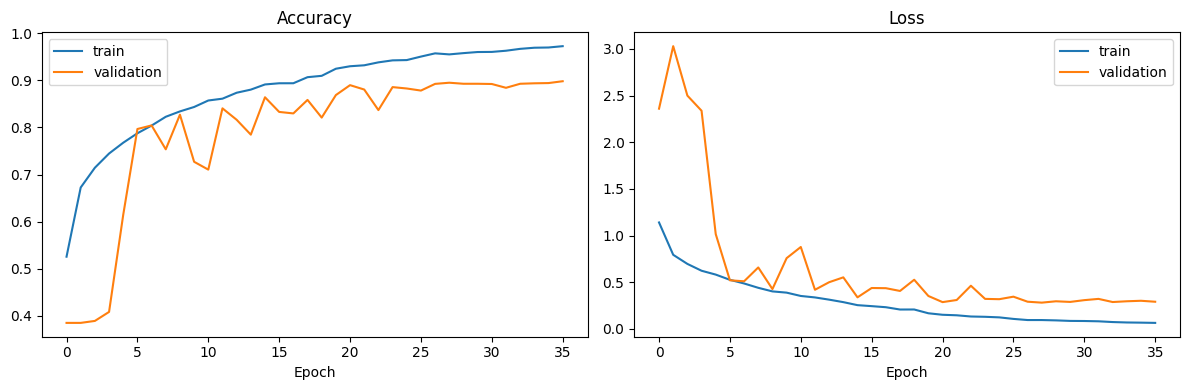

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='train')
ax[0].plot(history.history['val_accuracy'], label='validation')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['loss'], label='train')
ax[1].plot(history.history['val_loss'], label='validation')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
import os
p = "/content/drive/MyDrive/WM-811K-project/outputs/"
print(os.listdir(p))

['features.csv', 'features_v2.csv', 'rf_model.pkl', 'cnn_model.keras']


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

probs = model.predict(X_te, verbose=0)
cnn_pred = probs.argmax(axis=1)

print(f"CNN accuracy: {accuracy_score(y_te, cnn_pred):.1%}   (Random Forest: 88.3%)\n")
print(classification_report(y_te, cnn_pred, target_names=le.classes_, digits=3))

CNN accuracy: 88.9%   (Random Forest: 88.3%)

              precision    recall  f1-score   support

      Center      0.908     0.868     0.888       859
       Donut      0.756     0.811     0.783       111
    Edge-Loc      0.842     0.907     0.873      1038
   Edge-Ring      0.981     0.979     0.980      1936
         Loc      0.751     0.684     0.716       719
   Near-full      0.707     0.967     0.817        30
      Random      0.884     0.879     0.881       173
     Scratch      0.785     0.811     0.798       238

    accuracy                          0.889      5104
   macro avg      0.827     0.863     0.842      5104
weighted avg      0.889     0.889     0.888      5104



In [ ]:
model.save("/content/drive/MyDrive/WM-811K-project/outputs/cnn_model.keras")
print("Saved.")

Saved.


In [ ]:
model.save("/content/drive/MyDrive/WM-811K-project/outputs/cnn_model.keras")
print("Saved.")

Saved.


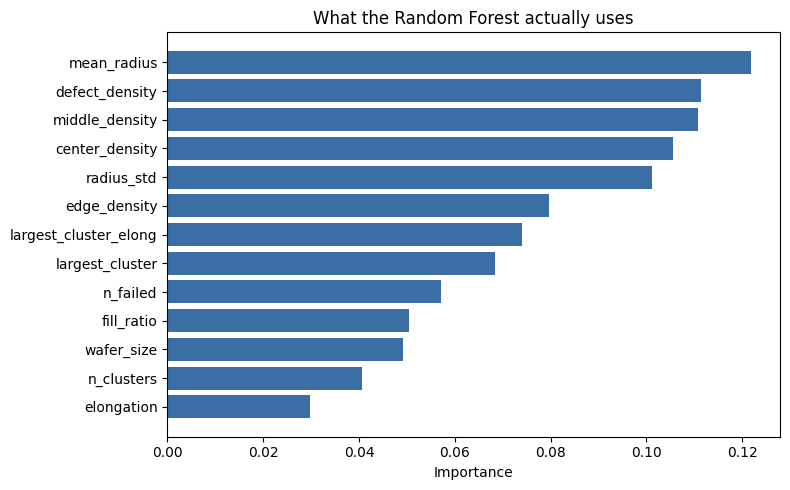

mean_radius              0.1218
defect_density           0.1114
middle_density           0.1107
center_density           0.1056
radius_std               0.1012
edge_density             0.0796
largest_cluster_elong    0.0740
largest_cluster          0.0684
n_failed                 0.0572
fill_ratio               0.0505
wafer_size               0.0492
n_clusters               0.0405
elongation               0.0298
dtype: float64


In [ ]:
import joblib
rf2 = joblib.load("/content/drive/MyDrive/WM-811K-project/outputs/rf_model.pkl")

feat2 = pd.read_csv("/content/drive/MyDrive/WM-811K-project/outputs/features_v2.csv")
X2 = feat2.drop(columns=['label'])

imp = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(imp.index, imp.values, color='#3b6ea5')
plt.xlabel('Importance')
plt.title('What the Random Forest actually uses')
plt.tight_layout(); plt.show()

print(imp.sort_values(ascending=False).round(4))

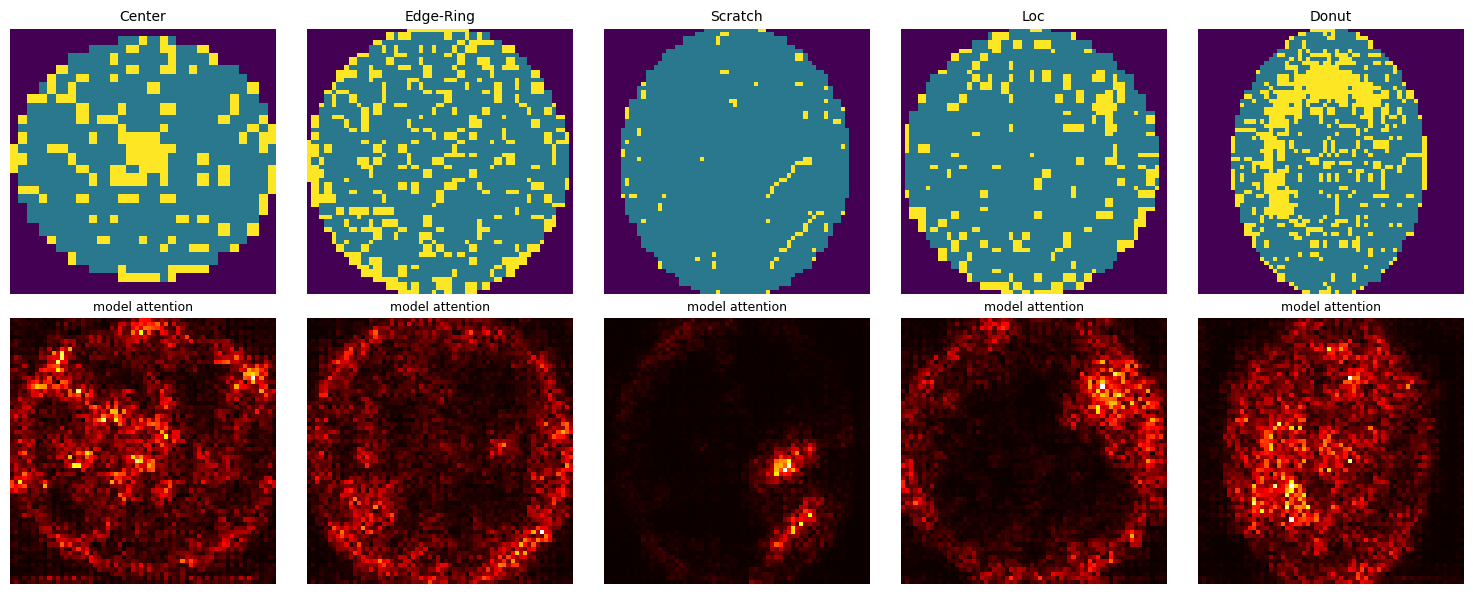

In [ ]:
import tensorflow as tf

def saliency(model, img):
    """Which pixels most affect the predicted class?"""
    x = tf.convert_to_tensor(img[None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x)
        top = pred[0, tf.argmax(pred[0])]
    grad = tape.gradient(top, x)[0]
    return tf.reduce_max(tf.abs(grad), axis=-1).numpy()


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(['Center','Edge-Ring','Scratch','Loc','Donut']):
    j = np.where(le.inverse_transform(y_te) == cls)[0][0]
    img = X_te[j]

    axes[0, i].imshow(img[:,:,1]*0.4 + img[:,:,2])
    axes[0, i].set_title(f"{cls}", fontsize=10)

    s = saliency(model, img)
    axes[1, i].imshow(s, cmap='hot')
    axes[1, i].set_title("model attention", fontsize=9)

    for r in range(2): axes[r, i].axis('off')

plt.tight_layout(); plt.show()

In [ ]:
from scipy import ndimage

def extract_features(wafer):
    h, w = wafer.shape
    cy, cx = h / 2, w / 2
    radius = np.sqrt(cy**2 + cx**2)
    on_wafer = (wafer == 1) | (wafer == 2)
    failed = (wafer == 2)
    n_chips, n_failed = on_wafer.sum(), failed.sum()

    f = {}
    f['defect_density'] = 0 if n_chips == 0 else n_failed / n_chips
    f['n_failed'] = n_failed
    f['wafer_size'] = n_chips

    yy, xx = np.ogrid[:h, :w]
    norm_dist = np.sqrt((yy - cy)**2 + (xx - cx)**2) / radius
    for name, lo, hi in [('center', 0, 0.4), ('middle', 0.4, 0.7), ('edge', 0.7, 1.1)]:
        ring = on_wafer & (norm_dist >= lo) & (norm_dist < hi)
        c = ring.sum()
        f[f'{name}_density'] = 0 if c == 0 else (failed & ring).sum() / c

    ys, xs = np.where(failed)
    if len(ys) == 0:
        f['mean_radius'] = f['radius_std'] = 0
        f['n_clusters'] = f['largest_cluster'] = 0
    else:
        d = np.sqrt((ys - cy)**2 + (xs - cx)**2) / radius
        f['mean_radius'], f['radius_std'] = d.mean(), d.std()
        lab, n = ndimage.label(failed)
        f['n_clusters'] = n
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        f['largest_cluster'] = 0 if n == 0 else sizes.max() / max(n_failed, 1)
    return f


def shape_features(wafer):
    failed = (wafer == 2)
    f = {'elongation': 0, 'largest_cluster_elong': 0, 'fill_ratio': 0}
    if failed.sum() < 3:
        return f

    ys, xs = np.where(failed)
    cov = np.cov(np.vstack([ys, xs]))
    ev = np.clip(np.linalg.eigvalsh(cov), 1e-9, None)
    f['elongation'] = 1 - (ev[0] / ev[1])

    lab, n = ndimage.label(failed)
    if n > 0:
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        big = (lab == (np.argmax(sizes) + 1))
        by, bx = np.where(big)
        if len(by) >= 3:
            c2 = np.cov(np.vstack([by, bx]))
            e2 = np.clip(np.linalg.eigvalsh(c2), 1e-9, None)
            f['largest_cluster_elong'] = 1 - (e2[0] / e2[1])
        h_box = by.max() - by.min() + 1
        w_box = bx.max() - bx.min() + 1
        f['fill_ratio'] = big.sum() / (h_box * w_box)
    return f


def extract_features_v2(wafer):
    f = extract_features(wafer)
    f.update(shape_features(wafer))
    return f

print("ready")

ready


In [ ]:
for cls in ['Edge-Ring', 'Scratch', 'Loc']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    r = analyze_wafer(w)
    print(f"\n--- true label: {cls}")
    for k, v in r.items():
        print(f"  {k:<22} {v}")


--- true label: Edge-Ring
  defect_density         0.212
  center_density         0.1186
  edge_density           0.4615
  mean_radius            0.554
  cluster_count          42
  largest_cluster_frac   0.1947
  elongation             0.9331
  fill_ratio             0.7333
  rf_prediction          Edge-Ring
  rf_confidence          0.647
  cnn_prediction         Edge-Loc
  cnn_confidence         0.885
  models_agree           False
  confidence             low - models disagree, manual review recommended

--- true label: Scratch
  defect_density         0.1632
  center_density         0.1751
  edge_density           0.3077
  mean_radius            0.465
  cluster_count          47
  largest_cluster_frac   0.1494
  elongation             0.9785
  fill_ratio             0.2708
  rf_prediction          Scratch
  rf_confidence          0.807
  cnn_prediction         Scratch
  cnn_confidence         0.999
  models_agree           True
  confidence             high

--- true label: Loc
  

In [ ]:
import joblib
rf2 = joblib.load("/content/drive/MyDrive/WM-811K-project/outputs/rf_model.pkl")
feat2 = pd.read_csv("/content/drive/MyDrive/WM-811K-project/outputs/features_v2.csv")
X2 = feat2.drop(columns=['label'])
print("loaded")

loaded


In [ ]:
def analyze_wafer(wafer):
    """Full analysis of a single wafer. Deterministic - no LLM here."""
    f = extract_features_v2(wafer)

    row = pd.DataFrame([f])[X2.columns]
    rf_pred = rf2.predict(row)[0]
    rf_conf = rf2.predict_proba(row)[0].max()

    img = prep_wafer(wafer)
    p = model.predict(img[None], verbose=0)[0]
    cnn_pred = le.classes_[p.argmax()]
    cnn_conf = float(p.max())

    agree = (rf_pred == cnn_pred)
    if agree and min(rf_conf, cnn_conf) > 0.7:
        confidence = "high"
    elif agree:
        confidence = "medium"
    else:
        confidence = "low - models disagree, manual review recommended"

    return {
        'defect_density': round(f['defect_density'], 4),
        'center_density': round(f['center_density'], 4),
        'edge_density': round(f['edge_density'], 4),
        'mean_radius': round(f['mean_radius'], 4),
        'cluster_count': int(f['n_clusters']),
        'largest_cluster_frac': round(f['largest_cluster'], 4),
        'elongation': round(f['largest_cluster_elong'], 4),
        'fill_ratio': round(f['fill_ratio'], 4),
        'rf_prediction': rf_pred,
        'rf_confidence': round(float(rf_conf), 3),
        'cnn_prediction': cnn_pred,
        'cnn_confidence': round(cnn_conf, 3),
        'models_agree': bool(agree),
        'confidence': confidence,
    }

print("ready")

ready


In [ ]:
for cls in ['Edge-Ring', 'Scratch', 'Loc']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    r = analyze_wafer(w)
    print(f"\n--- true label: {cls}")
    for k, v in r.items():
        print(f"  {k:<22} {v}")


--- true label: Edge-Ring
  defect_density         0.212
  center_density         0.1186
  edge_density           0.4615
  mean_radius            0.554
  cluster_count          42
  largest_cluster_frac   0.1947
  elongation             0.9331
  fill_ratio             0.7333
  rf_prediction          Edge-Ring
  rf_confidence          0.647
  cnn_prediction         Edge-Loc
  cnn_confidence         0.885
  models_agree           False
  confidence             low - models disagree, manual review recommended

--- true label: Scratch
  defect_density         0.1632
  center_density         0.1751
  edge_density           0.3077
  mean_radius            0.465
  cluster_count          47
  largest_cluster_frac   0.1494
  elongation             0.9785
  fill_ratio             0.2708
  rf_prediction          Scratch
  rf_confidence          0.807
  cnn_prediction         Scratch
  cnn_confidence         0.999
  models_agree           True
  confidence             high

--- true label: Loc
  

In [ ]:
import os
os.environ['ANTHROPIC_API_KEY'] = '88f1ef5747cd16c77fa0b6e90bb6f446'

In [ ]:
def write_note_template(a):
    """Deterministic excursion note. No API required."""
    pattern = a['rf_prediction'] if a['models_agree'] else \
              f"{a['rf_prediction']} or {a['cnn_prediction']} (disputed)"

    areas = {
        'Edge-Ring':  "edge-related process uniformity: bevel/edge exclusion, "
                      "chuck contact at the wafer rim, edge bead removal",
        'Edge-Loc':   "localized edge conditions: handling contact points, "
                      "clamp or chuck marks, asymmetric flow at the rim",
        'Center':     "centre-of-wafer conditions: chuck contact, rotation-speed "
                      "effects, centre gas distribution",
        'Donut':      "annular non-uniformity: rotational process symmetry, "
                      "radial flow or temperature gradients",
        'Scratch':    "mechanical handling: wafer transfer arms, contact points, "
                      "carrier or cassette damage",
        'Loc':        "a localized point source: particle contamination, a single "
                      "chamber position, a spot defect on tooling",
        'Random':     "distributed random failure: particle counts, ambient "
                      "contamination, general process control",
        'Near-full':  "a gross process excursion affecting the whole wafer: "
                      "recipe fault, tool malfunction, or misprocessing",
    }.get(a['rf_prediction'], "general process conditions")

    lines = [
        f"OBSERVED PATTERN",
        f"  {pattern}. {a['defect_density']:.1%} of dies failed.",
        "",
        f"EVIDENCE",
        f"  Regional failure rate: centre {a['center_density']:.1%}, "
        f"edge {a['edge_density']:.1%}.",
        f"  Mean defect radius {a['mean_radius']:.3f} (0 = centre, 1 = rim).",
        f"  {a['cluster_count']} clusters; largest holds "
        f"{a['largest_cluster_frac']:.1%} of failures.",
        f"  Elongation {a['elongation']:.3f}, fill ratio {a['fill_ratio']:.3f}.",
        "",
        f"INVESTIGATION AREAS",
        f"  Consider {areas}.",
        f"  This pattern indicates where to look. It does not establish a",
        f"  physical root cause and should be confirmed against tool logs.",
        "",
        f"CONFIDENCE: {a['confidence']}",
        f"  Feature model: {a['rf_prediction']} ({a['rf_confidence']:.1%})",
        f"  Image model:   {a['cnn_prediction']} ({a['cnn_confidence']:.1%})",
    ]
    return "\n".join(lines)


for cls in ['Edge-Ring', 'Scratch']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    print(f"\n{'='*60}\nTrue label: {cls}\n{'='*60}")
    print(write_note_template(analyze_wafer(w)))


True label: Edge-Ring
OBSERVED PATTERN
  Edge-Ring or Edge-Loc (disputed). 21.2% of dies failed.

EVIDENCE
  Regional failure rate: centre 11.9%, edge 46.2%.
  Mean defect radius 0.554 (0 = centre, 1 = rim).
  42 clusters; largest holds 19.5% of failures.
  Elongation 0.933, fill ratio 0.733.

INVESTIGATION AREAS
  Consider edge-related process uniformity: bevel/edge exclusion, chuck contact at the wafer rim, edge bead removal.
  This pattern indicates where to look. It does not establish a
  physical root cause and should be confirmed against tool logs.

CONFIDENCE: low - models disagree, manual review recommended
  Feature model: Edge-Ring (64.7%)
  Image model:   Edge-Loc (88.5%)

True label: Scratch
OBSERVED PATTERN
  Scratch. 16.3% of dies failed.

EVIDENCE
  Regional failure rate: centre 17.5%, edge 30.8%.
  Mean defect radius 0.465 (0 = centre, 1 = rim).
  47 clusters; largest holds 14.9% of failures.
  Elongation 0.979, fill ratio 0.271.

INVESTIGATION AREAS
  Consider mechani

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

rf_pred_test = rf2.predict(X2.iloc[y_te.shape[0]*0:0]) if False else None  # skip

print("=== FINAL RESULTS ===")
print(f"Dataset:        811,457 total -> 172,950 labeled -> 25,519 defects")
print(f"Test set:       {len(y_te):,} wafers")
print()
print(f"CNN accuracy:   {accuracy_score(y_te, cnn_pred):.1%}")
print(f"CNN macro-F1:   {f1_score(y_te, cnn_pred, average='macro'):.3f}")
print()
print("Random Forest (from earlier run): 88.3% accuracy, macro-F1 0.856")

=== FINAL RESULTS ===
Dataset:        811,457 total -> 172,950 labeled -> 25,519 defects
Test set:       5,104 wafers

CNN accuracy:   88.9%
CNN macro-F1:   0.842

Random Forest (from earlier run): 88.3% accuracy, macro-F1 0.856


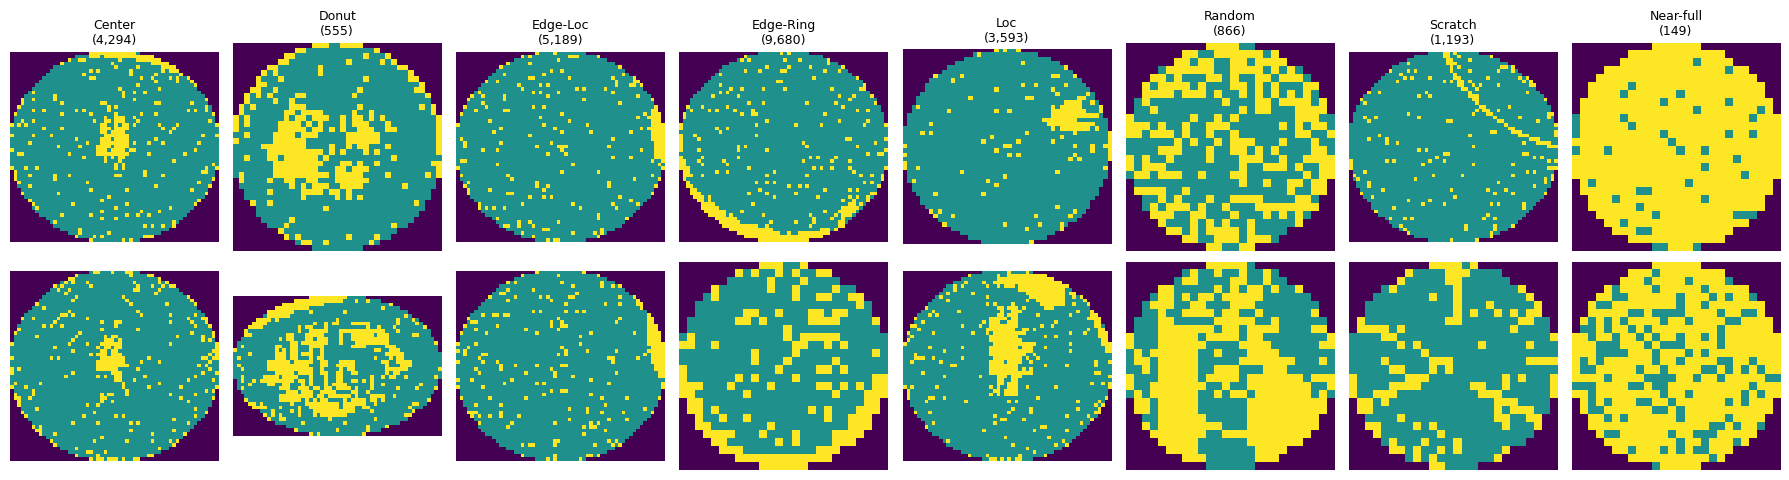

In [ ]:
import os
FIG = "/content/drive/MyDrive/WM-811K-project/outputs/figures"
os.makedirs(FIG, exist_ok=True)

# defect class grid
classes = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for c, cls in enumerate(classes):
    s = defects[defects.label == cls]
    for r in range(2):
        axes[r, c].imshow(s.iloc[r]['waferMap']); axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(f"{cls}\n({len(s):,})", fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/defect_classes.png", dpi=120); plt.show()

In [ ]:
from google.colab import files
!cd "/content/drive/MyDrive/WM-811K-project" && zip -r /content/project.zip outputs -x "*.pkl" "*.keras"
files.download('/content/project.zip')

  adding: outputs/ (stored 0%)
  adding: outputs/features.csv (deflated 70%)
  adding: outputs/features_v2.csv (deflated 67%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/defect_classes.png (deflated 16%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
out = []
for cls in ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    out.append(f"{'='*60}\nTrue label: {cls}\n{'='*60}\n")
    out.append(write_note_template(analyze_wafer(w)))
    out.append("\n\n")

path = "/content/drive/MyDrive/WM-811K-project/outputs/excursion_reports.txt"
with open(path, "w") as f:
    f.write("".join(out))
print("Saved to", path)

Saved to /content/drive/MyDrive/WM-811K-project/outputs/excursion_reports.txt


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/WM-811K-project/outputs/"))

['features.csv', 'features_v2.csv', 'rf_model.pkl', 'cnn_model.keras', 'figures', 'excursion_reports.txt']


In [ ]:
model.save("/content/drive/MyDrive/WM-811K-project/outputs/cnn_model.keras")

In [ ]:
!cd "/content/drive/MyDrive/WM-811K-project" && zip -r /content/project.zip outputs
from google.colab import files
files.download('/content/project.zip')

updating: outputs/ (stored 0%)
updating: outputs/features.csv (deflated 70%)
updating: outputs/features_v2.csv (deflated 67%)
updating: outputs/figures/ (stored 0%)
updating: outputs/figures/defect_classes.png (deflated 16%)
  adding: outputs/rf_model.pkl (deflated 79%)
  adding: outputs/cnn_model.keras (deflated 12%)
  adding: outputs/excursion_reports.txt (deflated 79%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, joblib

OUT = "/content/drive/MyDrive/WM-811K-project/outputs"
os.makedirs(f"{OUT}/figures", exist_ok=True)

model.save(f"{OUT}/cnn_model.keras")
joblib.dump(rf2, f"{OUT}/rf_model.pkl")
joblib.dump(le, f"{OUT}/label_encoder.pkl")
print("Models saved.")

Models saved.


In [ ]:
lines = []
for cls in ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    lines.append(f"\n{'='*60}\nTrue label: {cls}\n{'='*60}\n")
    lines.append(write_note_template(analyze_wafer(w)))

with open(f"{OUT}/excursion_reports.txt", "w") as f:
    f.write("\n".join(lines))
print("Reports saved.")

Reports saved.


In [ ]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

txt = []
txt.append("WM-811K WAFER DEFECT CLASSIFICATION - RESULTS\n")
txt.append(f"Dataset: 811,457 total | 172,950 labeled (21.3%) | 25,519 defects\n")
txt.append(f"Split: {len(X_tr):,} train | {len(X_val):,} val | {len(X_te):,} test\n")
txt.append(f"\nRANDOM FOREST (13 engineered features)")
txt.append(f"  Accuracy 88.3%   Macro-F1 0.856")
txt.append(f"\nCNN (64x64x3 images, ~103k params)")
txt.append(f"  Accuracy {accuracy_score(y_te, cnn_pred):.1%}   "
           f"Macro-F1 {f1_score(y_te, cnn_pred, average='macro'):.3f}\n")
txt.append(classification_report(y_te, cnn_pred, target_names=le.classes_, digits=3))

with open(f"{OUT}/results.txt", "w") as f:
    f.write("\n".join(txt))
print("\n".join(txt))

WM-811K WAFER DEFECT CLASSIFICATION - RESULTS

Dataset: 811,457 total | 172,950 labeled (21.3%) | 25,519 defects

Split: 16,332 train | 4,083 val | 5,104 test


RANDOM FOREST (13 engineered features)
  Accuracy 88.3%   Macro-F1 0.856

CNN (64x64x3 images, ~103k params)
  Accuracy 88.9%   Macro-F1 0.842

              precision    recall  f1-score   support

      Center      0.908     0.868     0.888       859
       Donut      0.756     0.811     0.783       111
    Edge-Loc      0.842     0.907     0.873      1038
   Edge-Ring      0.981     0.979     0.980      1936
         Loc      0.751     0.684     0.716       719
   Near-full      0.707     0.967     0.817        30
      Random      0.884     0.879     0.881       173
     Scratch      0.785     0.811     0.798       238

    accuracy                          0.889      5104
   macro avg      0.827     0.863     0.842      5104
weighted avg      0.889     0.889     0.888      5104



In [ ]:
FIG = f"{OUT}/figures"

# 1. defect classes
classes = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Random','Scratch','Near-full']
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for c, cls in enumerate(classes):
    s = defects[defects.label == cls]
    for r in range(2):
        axes[r, c].imshow(s.iloc[r]['waferMap']); axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(f"{cls}\n({len(s):,})", fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG}/defect_classes.png", dpi=120, bbox_inches='tight')
plt.close()

# 2. feature importance
imp = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values()
plt.figure(figsize=(8,5))
plt.barh(imp.index, imp.values, color='#3b6ea5')
plt.xlabel('Importance'); plt.title('Random Forest feature importance')
plt.tight_layout(); plt.savefig(f"{FIG}/feature_importance.png", dpi=120, bbox_inches='tight')
plt.close()

# 3. training curves
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(history.history['accuracy'], label='train')
ax[0].plot(history.history['val_accuracy'], label='validation')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(history.history['loss'], label='train')
ax[1].plot(history.history['val_loss'], label='validation')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/training_curves.png", dpi=120, bbox_inches='tight')
plt.close()

# 4. confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_te, cnn_pred)
fig, ax = plt.subplots(figsize=(9,7))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(8)); ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticks(range(8)); ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('CNN confusion matrix')
for i in range(8):
    for j in range(8):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG}/confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.close()

print("Figures saved.")

Figures saved.


In [ ]:
for root, dirs, fs in os.walk(OUT):
    for f in sorted(fs):
        p = os.path.join(root, f)
        print(f"{os.path.getsize(p)/1e6:8.2f} MB  {p.replace(OUT+'/','')}")

    1.29 MB  cnn_model.keras
    0.01 MB  excursion_reports.txt
    3.85 MB  features.csv
    5.25 MB  features_v2.csv
    0.00 MB  label_encoder.pkl
    0.00 MB  results.txt
  166.39 MB  rf_model.pkl
    0.05 MB  figures/confusion_matrix.png
    0.04 MB  figures/defect_classes.png
    0.04 MB  figures/feature_importance.png
    0.06 MB  figures/training_curves.png


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

X2 = feat2.drop(columns=['label'])
y2 = feat2['label']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

rf_pred = rf2.predict(X2_te)

rf_txt = []
rf_txt.append("RANDOM FOREST - 13 engineered features\n")
rf_txt.append(f"Accuracy: {accuracy_score(y2_te, rf_pred):.1%}")
rf_txt.append(f"Macro-F1: {f1_score(y2_te, rf_pred, average='macro'):.3f}\n")
rf_txt.append(classification_report(y2_te, rf_pred, digits=3))

with open(f"{OUT}/rf_results.txt", "w") as f:
    f.write("\n".join(rf_txt))
print("\n".join(rf_txt))

RANDOM FOREST - 13 engineered features

Accuracy: 88.3%
Macro-F1: 0.856

              precision    recall  f1-score   support

      Center      0.932     0.953     0.942       859
       Donut      0.794     0.730     0.761       111
    Edge-Loc      0.769     0.858     0.811      1038
   Edge-Ring      0.981     0.968     0.975      1936
         Loc      0.756     0.682     0.717       719
   Near-full      0.968     1.000     0.984        30
      Random      0.928     0.896     0.912       173
     Scratch      0.803     0.702     0.749       238

    accuracy                          0.883      5104
   macro avg      0.866     0.849     0.856      5104
weighted avg      0.884     0.883     0.882      5104



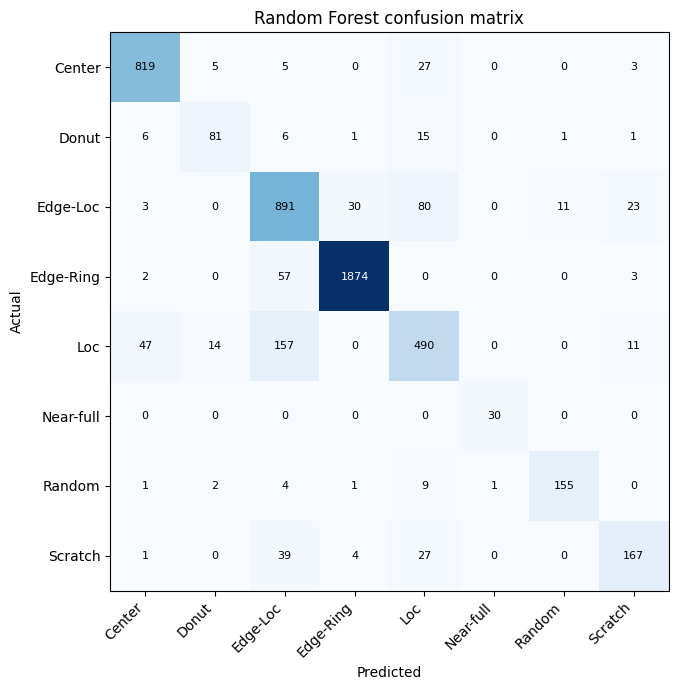

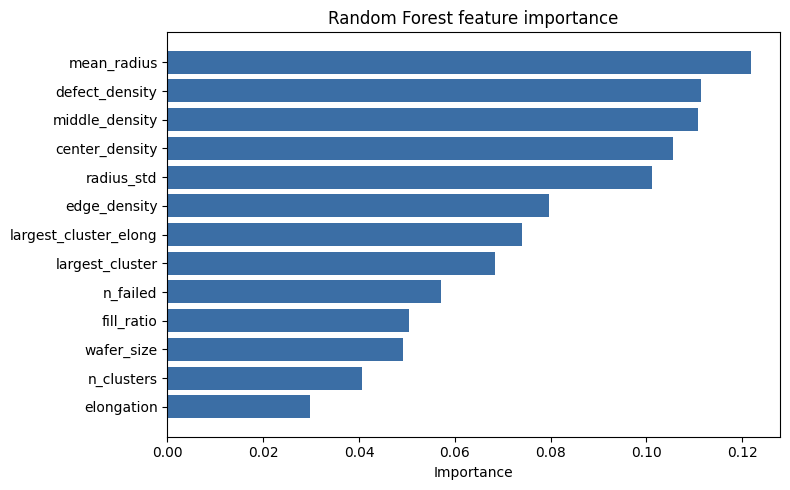

mean_radius              0.1218
defect_density           0.1114
middle_density           0.1107
center_density           0.1056
radius_std               0.1012
edge_density             0.0796
largest_cluster_elong    0.0740
largest_cluster          0.0684
n_failed                 0.0572
fill_ratio               0.0505
wafer_size               0.0492
n_clusters               0.0405
elongation               0.0298
dtype: float64


In [ ]:
# RF confusion matrix + feature importance
cls = sorted(y2.unique())
cm = confusion_matrix(y2_te, rf_pred, labels=cls)
fig, ax = plt.subplots(figsize=(9,7))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(8)); ax.set_xticklabels(cls, rotation=45, ha='right')
ax.set_yticks(range(8)); ax.set_yticklabels(cls)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest confusion matrix')
for i in range(8):
    for j in range(8):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=8,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout(); plt.savefig(f"{FIG}/rf_confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

imp = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values()
plt.figure(figsize=(8,5))
plt.barh(imp.index, imp.values, color='#3b6ea5')
plt.xlabel('Importance'); plt.title('Random Forest feature importance')
plt.tight_layout(); plt.savefig(f"{FIG}/feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()
print(imp.sort_values(ascending=False).round(4))

In [ ]:
readme = r"""
PASTE THE README CONTENT HERE
"""

path = "/content/drive/MyDrive/WM-811K-project/README.md"
with open(path, "w") as f:
    f.write(readme)
print("Saved to", path)

Saved to /content/drive/MyDrive/WM-811K-project/README.md


In [ ]:
readme = r"""
PASTE THE README CONTENT HERE
"""

path = "/content/drive/MyDrive/WM-811K-project/README.md"
with open(path, "w") as f:
    f.write(readme)
print("Saved to", path)

Saved to /content/drive/MyDrive/WM-811K-project/README.md


In [ ]:
import json

def tool_defect_density(wafer):
    f = extract_features_v2(wafer)
    return {"defect_density": round(f['defect_density'], 4),
            "n_failed": int(f['n_failed']),
            "wafer_size": int(f['wafer_size'])}

def tool_spatial_distribution(wafer):
    f = extract_features_v2(wafer)
    return {"center_density": round(f['center_density'], 4),
            "middle_density": round(f['middle_density'], 4),
            "edge_density": round(f['edge_density'], 4),
            "mean_radius": round(f['mean_radius'], 4),
            "radius_std": round(f['radius_std'], 4)}

def tool_cluster_analysis(wafer):
    f = extract_features_v2(wafer)
    return {"n_clusters": int(f['n_clusters']),
            "largest_cluster_frac": round(f['largest_cluster'], 4),
            "elongation": round(f['largest_cluster_elong'], 4),
            "fill_ratio": round(f['fill_ratio'], 4)}

def tool_classify(wafer):
    f = extract_features_v2(wafer)
    row = pd.DataFrame([f])[X2.columns]
    rf_p = rf2.predict(row)[0]
    rf_c = float(rf2.predict_proba(row)[0].max())
    p = model.predict(prep_wafer(wafer)[None], verbose=0)[0]
    return {"rf_prediction": rf_p, "rf_confidence": round(rf_c, 3),
            "cnn_prediction": le.classes_[p.argmax()],
            "cnn_confidence": round(float(p.max()), 3),
            "models_agree": bool(rf_p == le.classes_[p.argmax()])}

def tool_cnn_alternatives(wafer):
    """Second and third most likely classes - only useful when uncertain."""
    p = model.predict(prep_wafer(wafer)[None], verbose=0)[0]
    order = p.argsort()[::-1][:3]
    return {"top_3": [{"class": le.classes_[i], "prob": round(float(p[i]), 3)}
                      for i in order]}

def tool_class_prior(pattern):
    """How common is this pattern? Rare predictions deserve more scrutiny."""
    counts = defects.label.value_counts().to_dict()
    n = counts.get(pattern, 0)
    return {"pattern": pattern, "training_examples": int(n),
            "share_of_defects": round(n / len(defects), 4)}

TOOLS = {
    "defect_density": tool_defect_density,
    "spatial_distribution": tool_spatial_distribution,
    "cluster_analysis": tool_cluster_analysis,
    "classify": tool_classify,
    "cnn_alternatives": tool_cnn_alternatives,
}
print("tools registered")

tools registered


In [ ]:
def agent_investigate(wafer, verbose=True):
    """Investigates a wafer, deciding which tools to run based on findings."""
    trace = []

    def run(name, *args):
        fn = TOOLS[name] if name in TOOLS else tool_class_prior
        out = fn(*args)
        trace.append({"tool": name, "result": out})
        if verbose:
            print(f"  -> {name}: {json.dumps(out)}")
        return out

    if verbose: print("Investigating wafer...")

    # Always start with classification - it determines everything after
    cls = run("classify", wafer)

    # BRANCH 1: models disagree -> gather more evidence before concluding
    if not cls["models_agree"]:
        if verbose: print("  [models disagree - escalating investigation]")
        run("cnn_alternatives", wafer)
        run("spatial_distribution", wafer)
        run("cluster_analysis", wafer)
        prior_rf = run("class_prior", cls["rf_prediction"])
        prior_cnn = run("class_prior", cls["cnn_prediction"])
        verdict = "DISAGREEMENT - manual review required"
        rarer = (prior_rf if prior_rf["training_examples"]
                 < prior_cnn["training_examples"] else prior_cnn)
        reason = (f"Models split between {cls['rf_prediction']} and "
                  f"{cls['cnn_prediction']}. The rarer of the two "
                  f"({rarer['pattern']}, {rarer['training_examples']} training "
                  f"examples) carries higher uncertainty.")

    # BRANCH 2: agree but low confidence -> check what else it could be
    elif min(cls["rf_confidence"], cls["cnn_confidence"]) < 0.7:
        if verbose: print("  [agreement but low confidence - checking alternatives]")
        alts = run("cnn_alternatives", wafer)
        run("spatial_distribution", wafer)
        verdict = "LOW CONFIDENCE - recommend review"
        runner_up = alts["top_3"][1]
        reason = (f"Both models predict {cls['rf_prediction']}, but confidence "
                  f"is below threshold. Nearest alternative is "
                  f"{runner_up['class']} at {runner_up['prob']}.")

    # BRANCH 3: confident agreement -> minimal evidence, done
    else:
        if verbose: print("  [confident agreement - collecting evidence]")
        run("spatial_distribution", wafer)
        run("cluster_analysis", wafer)
        verdict = "CONFIRMED"
        reason = (f"Both models independently predict {cls['rf_prediction']} "
                  f"with confidence {cls['rf_confidence']} and "
                  f"{cls['cnn_confidence']}.")

    return {"verdict": verdict, "reasoning": reason,
            "tools_called": len(trace), "trace": trace}

In [ ]:
for cls_name in ['Edge-Ring', 'Scratch', 'Near-full']:
    w = defects[defects.label == cls_name].iloc[5]['waferMap']
    print(f"\n{'='*62}\nTRUE LABEL: {cls_name}\n{'='*62}")
    r = agent_investigate(w)
    print(f"\nVERDICT: {r['verdict']}")
    print(f"REASONING: {r['reasoning']}")
    print(f"Tools called: {r['tools_called']}")


TRUE LABEL: Edge-Ring
Investigating wafer...
  -> classify: {"rf_prediction": "Edge-Ring", "rf_confidence": 0.647, "cnn_prediction": "Edge-Loc", "cnn_confidence": 0.885, "models_agree": false}
  [models disagree - escalating investigation]
  -> cnn_alternatives: {"top_3": [{"class": "Edge-Loc", "prob": 0.885}, {"class": "Edge-Ring", "prob": 0.115}, {"class": "Loc", "prob": 0.0}]}
  -> spatial_distribution: {"center_density": 0.1186, "middle_density": 0.2424, "edge_density": 0.4615, "mean_radius": 0.554, "radius_std": 0.1751}
  -> cluster_analysis: {"n_clusters": 42, "largest_cluster_frac": 0.1947, "elongation": 0.9331, "fill_ratio": 0.7333}
  -> class_prior: {"pattern": "Edge-Ring", "training_examples": 9680, "share_of_defects": 0.3793}
  -> class_prior: {"pattern": "Edge-Loc", "training_examples": 5189, "share_of_defects": 0.2033}

VERDICT: DISAGREEMENT - manual review required
REASONING: Models split between Edge-Ring and Edge-Loc. The rarer of the two (Edge-Loc, 5189 training examp

In [ ]:
lines = []
for cls_name in ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch']:
    w = defects[defects.label == cls_name].iloc[5]['waferMap']
    r = agent_investigate(w, verbose=False)
    lines.append(f"\n{'='*62}\nTRUE LABEL: {cls_name}\n{'='*62}")
    lines.append(f"VERDICT: {r['verdict']}")
    lines.append(f"REASONING: {r['reasoning']}")
    lines.append(f"Tools called: {r['tools_called']}")
    for t in r['trace']:
        lines.append(f"  -> {t['tool']}: {t['result']}")

with open(f"{OUT}/agent_investigations.txt", "w") as f:
    f.write("\n".join(lines))
print("Saved.")
print("\n".join(lines[:20]))

Saved.

TRUE LABEL: Center
VERDICT: CONFIRMED
REASONING: Both models independently predict Center with confidence 0.873 and 0.981.
Tools called: 3
  -> classify: {'rf_prediction': 'Center', 'rf_confidence': 0.873, 'cnn_prediction': 'Center', 'cnn_confidence': 0.981, 'models_agree': True}
  -> spatial_distribution: {'center_density': np.float64(0.1243), 'middle_density': np.float64(0.1697), 'edge_density': np.float64(0.3077), 'mean_radius': np.float64(0.5162), 'radius_std': np.float64(0.2077)}
  -> cluster_analysis: {'n_clusters': 53, 'largest_cluster_frac': np.float64(0.1163), 'elongation': np.float64(0.2857), 'fill_ratio': np.float64(0.625)}

TRUE LABEL: Donut
VERDICT: CONFIRMED
REASONING: Both models independently predict Donut with confidence 0.937 and 0.999.
Tools called: 3
  -> classify: {'rf_prediction': 'Donut', 'rf_confidence': 0.937, 'cnn_prediction': 'Donut', 'cnn_confidence': 0.999, 'models_agree': True}
  -> spatial_distribution: {'center_density': np.float64(0.5839), 'midd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np
BASE = "/content/drive/MyDrive/WM-811K-project"
OUT = f"{BASE}/outputs"

df = pd.read_pickle(f"{BASE}/data/LSWMD.pkl")

def flatten_label(v):
    if isinstance(v, (np.ndarray, list)):
        if len(v) == 0: return None
        v = v[0]
        if isinstance(v, (np.ndarray, list)): v = v[0] if len(v) else None
    if v is None: return None
    s = str(v).strip()
    return s if s else None

df['label'] = df.failureType.apply(flatten_label)
defects = df[df.label.notna() & (df.label != 'none')].copy()
print("defects:", len(defects))

Mounted at /content/drive
defects: 25519


In [ ]:
from scipy.ndimage import zoom
SIZE = 64

def prep_wafer(wafer):
    h, w = wafer.shape
    scale = min(SIZE / h, SIZE / w)
    r = np.round(zoom(wafer.astype(float), (scale, scale), order=0)).astype(int)
    rh, rw = min(r.shape[0], SIZE), min(r.shape[1], SIZE)
    out = np.zeros((SIZE, SIZE), dtype=int)
    t, l = (SIZE - rh) // 2, (SIZE - rw) // 2
    out[t:t+rh, l:l+rw] = r[:rh, :rw]
    return np.stack([(out == 0), (out == 1), (out == 2)], axis=-1).astype(np.float32)

In [ ]:
import joblib
from tensorflow import keras

rf2 = joblib.load(f"{OUT}/rf_model.pkl")
model = keras.models.load_model(f"{OUT}/cnn_model.keras")
le = joblib.load(f"{OUT}/label_encoder.pkl")

feat2 = pd.read_csv(f"{OUT}/features_v2.csv")
X2 = feat2.drop(columns=['label'])
print("loaded:", list(le.classes_))

loaded: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(defects['label'])

In [ ]:
for name in ['defects', 'extract_features_v2', 'prep_wafer', 'rf2', 'model', 'le', 'X2']:
    print(f"{name:<22} {'OK' if name in dir() else 'MISSING'}")

defects                OK
extract_features_v2    MISSING
prep_wafer             OK
rf2                    OK
model                  OK
le                     OK
X2                     OK


In [ ]:
from scipy import ndimage

def extract_features(wafer):
    h, w = wafer.shape
    cy, cx = h / 2, w / 2
    radius = np.sqrt(cy**2 + cx**2)
    on_wafer = (wafer == 1) | (wafer == 2)
    failed = (wafer == 2)
    n_chips, n_failed = on_wafer.sum(), failed.sum()

    f = {}
    f['defect_density'] = 0 if n_chips == 0 else n_failed / n_chips
    f['n_failed'] = n_failed
    f['wafer_size'] = n_chips

    yy, xx = np.ogrid[:h, :w]
    nd = np.sqrt((yy - cy)**2 + (xx - cx)**2) / radius
    for name, lo, hi in [('center', 0, 0.4), ('middle', 0.4, 0.7), ('edge', 0.7, 1.1)]:
        ring = on_wafer & (nd >= lo) & (nd < hi)
        c = ring.sum()
        f[f'{name}_density'] = 0 if c == 0 else (failed & ring).sum() / c

    ys, xs = np.where(failed)
    if len(ys) == 0:
        f['mean_radius'] = f['radius_std'] = 0
        f['n_clusters'] = f['largest_cluster'] = 0
    else:
        d = np.sqrt((ys - cy)**2 + (xs - cx)**2) / radius
        f['mean_radius'], f['radius_std'] = d.mean(), d.std()
        lab, n = ndimage.label(failed)
        f['n_clusters'] = n
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        f['largest_cluster'] = 0 if n == 0 else sizes.max() / max(n_failed, 1)
    return f


def shape_features(wafer):
    failed = (wafer == 2)
    f = {'elongation': 0, 'largest_cluster_elong': 0, 'fill_ratio': 0}
    if failed.sum() < 3:
        return f
    ys, xs = np.where(failed)
    ev = np.clip(np.linalg.eigvalsh(np.cov(np.vstack([ys, xs]))), 1e-9, None)
    f['elongation'] = 1 - (ev[0] / ev[1])

    lab, n = ndimage.label(failed)
    if n > 0:
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        big = (lab == (np.argmax(sizes) + 1))
        by, bx = np.where(big)
        if len(by) >= 3:
            e2 = np.clip(np.linalg.eigvalsh(np.cov(np.vstack([by, bx]))), 1e-9, None)
            f['largest_cluster_elong'] = 1 - (e2[0] / e2[1])
        f['fill_ratio'] = big.sum() / ((by.max()-by.min()+1) * (bx.max()-bx.min()+1))
    return f


def extract_features_v2(wafer):
    f = extract_features(wafer)
    f.update(shape_features(wafer))
    return f

print("ready")

ready


In [ ]:
feat.to_csv("/content/drive/MyDrive/WM-811K-project/outputs/features.csv", index=False)
print("Saved.")

Saved.


In [ ]:
out = []
for cls in ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch']:
    w = defects[defects.label == cls].iloc[5]['waferMap']
    out.append(f"{'='*60}\nTrue label: {cls}\n{'='*60}\n")
    out.append(write_note_template(analyze_wafer(w)))
    out.append("\n\n")

path = "/content/drive/MyDrive/WM-811K-project/outputs/excursion_reports.txt"
with open(path, "w") as f:
    f.write("".join(out))
print("Saved to", path)

Saved to /content/drive/MyDrive/WM-811K-project/outputs/excursion_reports.txt


In [ ]:
print(feat.groupby('label')[
    ['defect_density','center_density','edge_density',
     'mean_radius','radius_std','largest_cluster']
].mean().round(3))

           defect_density  center_density  edge_density  mean_radius  \
label                                                                  
Center              0.232           0.309         0.521        0.434   
Donut               0.277           0.448         0.329        0.411   
Edge-Loc            0.183           0.119         0.419        0.541   
Edge-Ring           0.151           0.060         0.854        0.604   
Loc                 0.150           0.159         0.273        0.490   
Near-full           0.877           0.905         0.877        0.464   
Random              0.481           0.486         0.631        0.472   
Scratch             0.101           0.084         0.234        0.512   

           radius_std  largest_cluster  
label                                   
Center          0.212            0.276  
Donut           0.164            0.518  
Edge-Loc        0.164            0.285  
Edge-Ring       0.148            0.262  
Loc             0.167            

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = feat.drop(columns=['label'])
y = feat['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training on {len(X_train):,}   Testing on {len(X_test):,}")
print("\nTest set class counts:")
print(y_test.value_counts())

Training on 20,415   Testing on 5,104

Test set class counts:
label
Edge-Ring    1936
Edge-Loc     1038
Center        859
Loc           719
Scratch       238
Random        173
Donut         111
Near-full      30
Name: count, dtype: int64


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Trained.")

Trained.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

pred = rf.predict(X_test)

print(f"Overall accuracy: {accuracy_score(y_test, pred):.1%}\n")
print(classification_report(y_test, pred, digits=3))

Overall accuracy: 85.3%

              precision    recall  f1-score   support

      Center      0.913     0.959     0.935       859
       Donut      0.790     0.748     0.769       111
    Edge-Loc      0.734     0.844     0.785      1038
   Edge-Ring      0.976     0.950     0.963      1936
         Loc      0.681     0.661     0.670       719
   Near-full      0.968     1.000     0.984        30
      Random      0.894     0.879     0.886       173
     Scratch      0.630     0.315     0.420       238

    accuracy                          0.853      5104
   macro avg      0.823     0.794     0.802      5104
weighted avg      0.851     0.853     0.849      5104



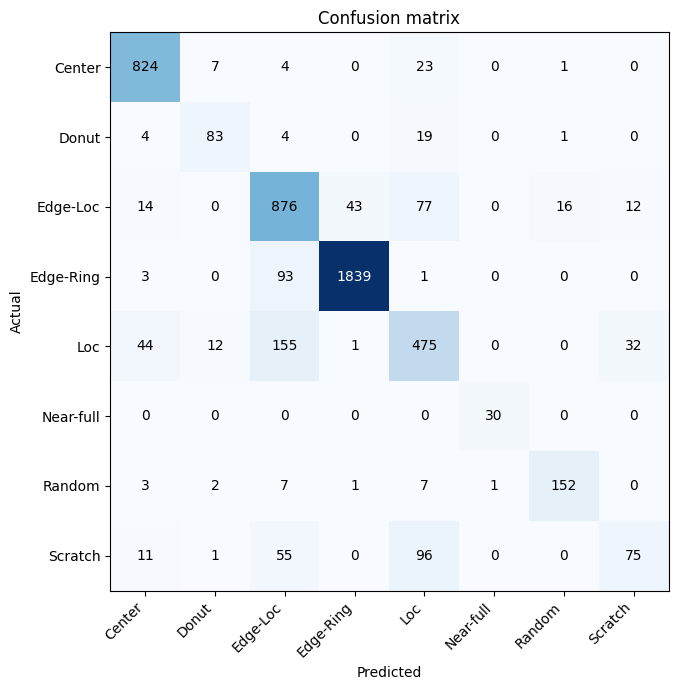

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

classes = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=classes)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.title('Confusion matrix')
plt.tight_layout(); plt.show()

In [ ]:
from scipy import ndimage

def shape_features(wafer):
    failed = (wafer == 2)
    f = {'elongation': 0, 'largest_cluster_elong': 0, 'fill_ratio': 0}
    if failed.sum() < 3:
        return f

    ys, xs = np.where(failed)

    # Elongation of ALL failed chips: how stretched is the overall cloud?
    # Eigenvalues of the covariance matrix give the spread along the two
    # principal axes. A line has one big, one tiny. A circle has two equal.
    cov = np.cov(np.vstack([ys, xs]))
    ev = np.linalg.eigvalsh(cov)
    ev = np.clip(ev, 1e-9, None)
    f['elongation'] = 1 - (ev[0] / ev[1])   # 0 = round, near 1 = line

    # Same measure, but for the single biggest connected blob
    lab, n = ndimage.label(failed)
    if n > 0:
        sizes = ndimage.sum(failed, lab, range(1, n + 1))
        big = (lab == (np.argmax(sizes) + 1))
        by, bx = np.where(big)
        if len(by) >= 3:
            c2 = np.cov(np.vstack([by, bx]))
            e2 = np.clip(np.linalg.eigvalsh(c2), 1e-9, None)
            f['largest_cluster_elong'] = 1 - (e2[0] / e2[1])

        # Fill ratio: does the blob fill its bounding box, or is it a thin
        # diagonal streak rattling around inside one?
        h_box = by.max() - by.min() + 1
        w_box = bx.max() - bx.min() + 1
        f['fill_ratio'] = big.sum() / (h_box * w_box)

    return f


# check it separates Scratch from Loc
for cls in ['Scratch', 'Loc', 'Center', 'Edge-Ring']:
    vals = [shape_features(w) for w in defects[defects.label == cls].waferMap.head(200)]
    e = np.mean([v['elongation'] for v in vals])
    le = np.mean([v['largest_cluster_elong'] for v in vals])
    fr = np.mean([v['fill_ratio'] for v in vals])
    print(f"{cls:<11} elongation={e:.3f}  cluster_elong={le:.3f}  fill_ratio={fr:.3f}")

Scratch     elongation=0.347  cluster_elong=0.861  fill_ratio=0.456
Loc         elongation=0.484  cluster_elong=0.601  fill_ratio=0.573
Center      elongation=0.291  cluster_elong=0.496  fill_ratio=0.578
Edge-Ring   elongation=0.120  cluster_elong=0.779  fill_ratio=0.167


In [ ]:
def extract_features_v2(wafer):
    f = extract_features(wafer)      # your original ten
    f.update(shape_features(wafer))  # plus the three new ones
    return f

import time
start = time.time()

rows = []
for i, (_, r) in enumerate(defects.iterrows()):
    f = extract_features_v2(r['waferMap'])
    f['label'] = r['label']
    rows.append(f)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1:,} / {len(defects):,}")

feat2 = pd.DataFrame(rows)
print(f"\nDone in {time.time()-start:.0f}s   Shape: {feat2.shape}")

feat2.to_csv("/content/drive/MyDrive/WM-811K-project/outputs/features_v2.csv", index=False)
print("Saved.")

  5,000 / 25,519
  10,000 / 25,519
  15,000 / 25,519
  20,000 / 25,519
  25,000 / 25,519

Done in 35s   Shape: (25519, 14)
Saved.


In [ ]:
X2 = feat2.drop(columns=['label'])
y2 = feat2['label']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf2 = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf2.fit(X2_train, y2_train)
pred2 = rf2.predict(X2_test)

print(f"Accuracy: {accuracy_score(y2_test, pred2):.1%}  (was 85.3%)\n")
print(classification_report(y2_test, pred2, digits=3))

Accuracy: 88.3%  (was 85.3%)

              precision    recall  f1-score   support

      Center      0.932     0.953     0.942       859
       Donut      0.794     0.730     0.761       111
    Edge-Loc      0.769     0.858     0.811      1038
   Edge-Ring      0.981     0.968     0.975      1936
         Loc      0.756     0.682     0.717       719
   Near-full      0.968     1.000     0.984        30
      Random      0.928     0.896     0.912       173
     Scratch      0.803     0.702     0.749       238

    accuracy                          0.883      5104
   macro avg      0.866     0.849     0.856      5104
weighted avg      0.884     0.883     0.882      5104



In [ ]:
imp = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print(imp.round(4))

mean_radius              0.1218
defect_density           0.1114
middle_density           0.1107
center_density           0.1056
radius_std               0.1012
edge_density             0.0796
largest_cluster_elong    0.0740
largest_cluster          0.0684
n_failed                 0.0572
fill_ratio               0.0505
wafer_size               0.0492
n_clusters               0.0405
elongation               0.0298
dtype: float64


In [ ]:
import joblib
joblib.dump(rf2, "/content/drive/MyDrive/WM-811K-project/outputs/rf_model.pkl")
print("Saved.")

Saved.


In [ ]:
imp = pd.Series(rf2.feature_importances_, index=X2.columns).sort_values(ascending=False)
print(imp.round(4))

mean_radius              0.1218
defect_density           0.1114
middle_density           0.1107
center_density           0.1056
radius_std               0.1012
edge_density             0.0796
largest_cluster_elong    0.0740
largest_cluster          0.0684
n_failed                 0.0572
fill_ratio               0.0505
wafer_size               0.0492
n_clusters               0.0405
elongation               0.0298
dtype: float64


In [ ]:
import joblib
joblib.dump(rf2, "/content/drive/MyDrive/WM-811K-project/outputs/rf_model.pkl")
print("Model saved.")

Model saved.


In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: []


In [ ]:
from scipy.ndimage import zoom

SIZE = 64

def prep_wafer(wafer):
    h, w = wafer.shape
    resized = zoom(wafer.astype(float), (SIZE/h, SIZE/w), order=0)
    resized = np.round(resized).astype(int)[:SIZE, :SIZE]

    # Pad if rounding left it a pixel short
    out = np.zeros((SIZE, SIZE), dtype=int)
    out[:resized.shape[0], :resized.shape[1]] = resized

    # Three channels: background, good chip, failed chip.
    # Keeping them separate matters - the values 0/1/2 are categories,
    # not brightness levels. Treating them as grayscale would tell the
    # network that "failed" is somehow twice as much as "good".
    stack = np.stack([(out == 0), (out == 1), (out == 2)], axis=-1)
    return stack.astype(np.float32)


test = prep_wafer(defects.iloc[0]['waferMap'])
print("Shape:", test.shape)
print("Original was:", defects.iloc[0]['waferMap'].shape)

Shape: (64, 64, 3)
Original was: (45, 48)


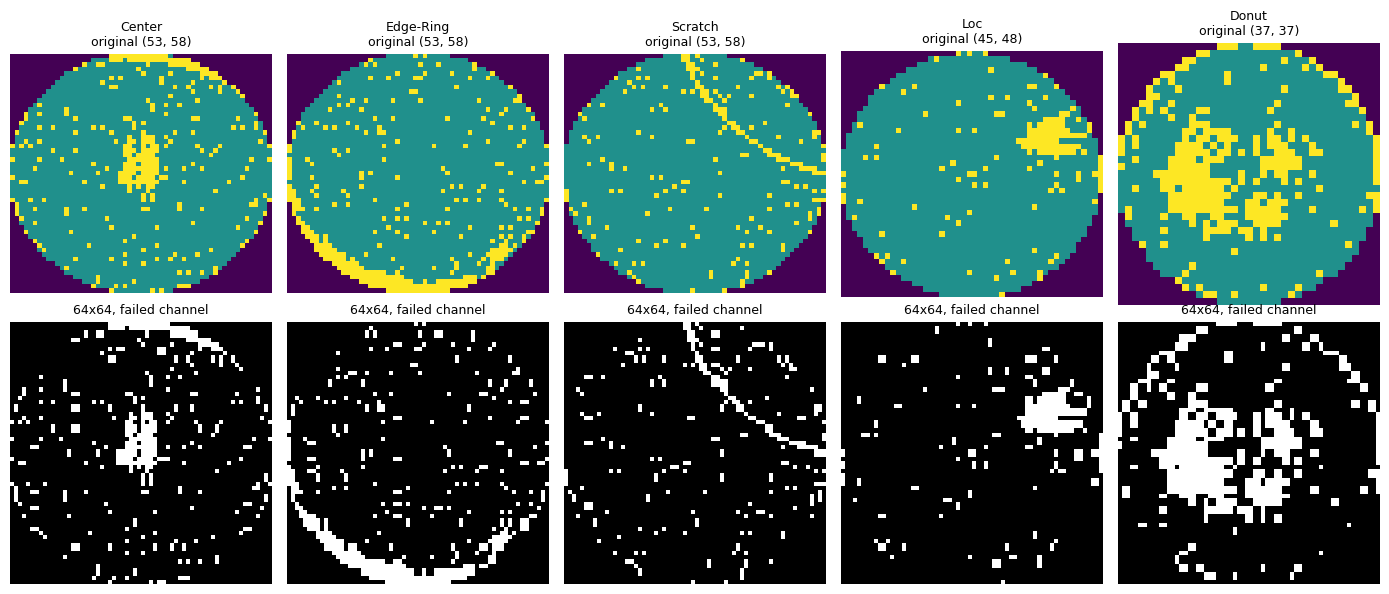

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, cls in enumerate(['Center','Edge-Ring','Scratch','Loc','Donut']):
    w = defects[defects.label == cls].iloc[0]['waferMap']
    axes[0, i].imshow(w); axes[0, i].set_title(f"{cls}\noriginal {w.shape}", fontsize=9)
    axes[1, i].imshow(prep_wafer(w)[:, :, 2], cmap='gray')
    axes[1, i].set_title("64x64, failed channel", fontsize=9)
    for r in range(2):
        axes[r, i].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

print("Converting all wafers...")
X_img = np.stack([prep_wafer(w) for w in defects['waferMap']])

le = LabelEncoder()
y_enc = le.fit_transform(defects['label'])

print("X shape:", X_img.shape)
print("Classes:", list(le.classes_))

Converting all wafers...
X shape: (25519, 64, 64, 3)
Classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']


In [ ]:
from sklearn.model_selection import train_test_split

# First: peel off 20% as the sealed test set
X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_img, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# Then: split the remainder into training and validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.2, random_state=42, stratify=y_tr_full)

print(f"Train:      {len(X_tr):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test:       {len(X_te):,}")

Train:      16,332
Validation: 4,083
Test:       5,104


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(weights))

for i, c in enumerate(le.classes_):
    print(f"  {c:<12} weight {class_weights[i]:.2f}")

  Center       weight 0.74
  Donut        weight 5.75
  Edge-Loc     weight 0.61
  Edge-Ring    weight 0.33
  Loc          weight 0.89
  Near-full    weight 21.49
  Random       weight 3.68
  Scratch      weight 2.67


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(8, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,920 (402.03 KB)

 Trainable params: 102,472 (400.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
147/256 ━━━━━━━━━━━━━━━━━━━━ 1:42 941ms/step - accuracy: 0.4021 - loss: 1.4590

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
